#Gabrielle Johnson's Week 6 Interim Deliverable


##Importing Libraries 📚

In [ ]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: loads the Python "tools" (libraries) we need.
#   - pandas: works with tables of data (like a spreadsheet in code)
#   - matplotlib: draws charts
#   - scikit-learn (sklearn): the machine-learning toolkit
#   - joblib: saves a trained model to a file so we can reuse it later
# You only run this once at the top of the notebook.
# ------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
#os.makedirs("figs", exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import precision_score
from pathlib import Path
from google.colab import drive

pd.set_option("display.width", 120)
print("Libraries loaded. ✅")

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score, recall_score,
)

Libraries loaded. ✅


## Setting up the Environment ⚙

In [ ]:
# mount Drive
drive.mount("/content/drive")
DATA_PATH = Path("/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find {DATA_PATH}. Place the CSV beside this notebook, or set DATA_PATH (Colab).")

# index_col=0 drops the unnamed export row-number column
df = pd.read_csv(DATA_PATH, index_col=0)
print(f"Loaded {df.shape[0]:,} ED encounters  x  {df.shape[1]} columns")

#inspecting the data
#df.head()

Mounted at /content/drive
Loaded 55,121 ED encounters  x  225 columns


## Categorise Columns 🔗

In [ ]:
TARGET = "esi"

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

chief_complaints = [col for col in df.columns if col.startswith("cc_")]

In [ ]:
# Reference ranges for general adult triage since there are no paediatric patients. Each entry is (low, high, unit).
NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), "triage_glucose": (70,140,"mg/dL")}

# "Plausible" bounds are much wider than normal — anything OUTSIDE these is treated as a
# data error (e.g. a heart rate of 5). Each entry is (low, high).
PLAUSIBLE = {"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_glucose": (20,800)}

##Cleaning the Dataset 🧼

In [ ]:
def clean_triage(raw):
    """
    Takes the raw DataFrame and returns a cleaned copy.
    """
    d = raw.copy()

    # Drop rows with no esi
    d = d[d[TARGET].notna()].copy()

    # Convert expected numeric fields to numeric
    numeric_cols = [c for c in VITALS if c in d.columns]
    if "age" in d.columns:
        numeric_cols.append("age")
    numeric_cols.append(TARGET)

    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # Drop rows where ESI became invalid after numeric conversion
    d = d[d[TARGET].notna()].copy()

    # Add impossible value flags only if implausible values exist
    for col, (low, high) in PLAUSIBLE.items():
        if col in d.columns:
            out_of_range = (d[col] < low) | (d[col] > high)
            if out_of_range.any():
                d[f"{col}_was_impossible"] = out_of_range.astype(int)

    # Add missingness flags only for vitals that have missing values
    for col in VITALS:
        if col in d.columns and d[col].isna().sum() > 0:
            d[f"{col}_was_missing"] = d[col].isna().astype(int)
            d[col] = d[col].fillna(d[col].median())

    # Oxygen device flag: blank means no device recorded
    if "triage_vital_o2_device" in d.columns:
        d["triage_vital_o2_device"] = (
            pd.to_numeric(d["triage_vital_o2_device"], errors="coerce").fillna(0)
        )

    # Clean chief complaint flags
    for col in chief_complaints:
        d[col] = pd.to_numeric(d[col], errors="coerce").fillna(0)
        d[col] = (d[col] == 1).astype(int)

    # Clean categorical text columns
    for col in DEMOGRAPHICS + ADMIN + LEAKAGE:
        if col in d.columns and d[col].dtype == object:
            d[col] = (
                d[col].astype(str).str.strip()
                .replace({"": "Unknown", "nan": "Unknown", "NaN": "Unknown",
                          "None": "Unknown", "NONE": "Unknown"})
                .fillna("Unknown")
            )

    # Convert target to integer
    d[TARGET] = d[TARGET].round().astype(int)

    return d

In [ ]:
df=clean_triage(df)
#df.head()

##Choosing the Features (X) and the Target (y)

In [ ]:
X = df[FEATURES]     #the clues the model may use to make that prediction
y = df[TARGET]       #the thing we want to PREDICT  -> esi (the triage level 1-5)

print("Model will use", len(FEATURES), "features to predict:", TARGET)
print("First few features:", FEATURES[:10], "...")

Model will use 208 features to predict: esi
First few features: ['triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device', 'triage_vital_temp', 'triage_glucose', 'cc_abdominalcramping', 'cc_abdominaldistention'] ...


##Split into training and test sets 🏋
> Uses random_state= 42

In [ ]:
#separates a TEST set (20%) that the model will not see during training, so later we can grade it honestly.
#stratify=y keeps the ESI mix balanced across both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Training patients:", X_train.shape[0])
print("Testing patients: ", X_test.shape[0])

Training patients: 44096
Testing patients:  11025


## A baseline to beat (DummyClassifier) 🥊

In [ ]:
#prediction based only on the class distribution, not on the features
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
print(f"Dummy baseline accuracy: {dummy.score(X_test, y_test):.2f}")

Dummy baseline accuracy: 0.38


In [ ]:
pred_dummy = dummy.predict(X_test)
print(f"Dummy baseline accuracy: {dummy.score(X_test, y_test):.2f}")

Dummy baseline accuracy: 0.38


##Logistic Regression 🧠♻






In [ ]:
# scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# train the model
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
print(f"Scaled logistic regression test accuracy: {logreg.score(X_test_scaled, y_test):.3f}")



Scaled logistic regression test accuracy: 0.667


## Predictions on the Test Set

In [ ]:
#get the predicted ESI for the test set.
pred_logreg =logreg.predict(X_test_scaled)
print("Example predictions (logreg):", pred_logreg[:10])

Example predictions (logreg): [2 3 3 2 2 2 3 3 3 2]


## Confusion Matrix 🔍

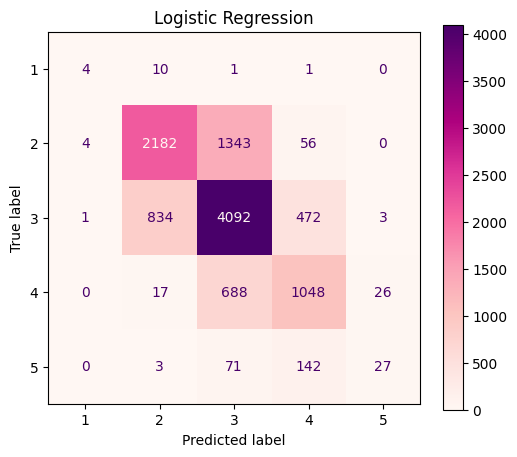

In [ ]:
#confusion matrix
# Rows = true ESI, columns = predicted ESI. Diagonal = correct.
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax, cmap="RdPu")
ax.set_title("Logistic Regression")
fig.savefig("/content/drive/MyDrive/confusion_matrix_logreg.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Accuracy, Precision, Recall, F1, Classification Report 📊📝




In [ ]:
#weighted f1 score- weighted by class size,Skews toward the majority class.
f1_weighted=f1_score(y_test, pred_logreg, average='weighted')
print(f"F1_Score Weighted: {f1_weighted:.3f}")

#macro f1 score - every esi level counts equally
f1_macro=f1_score(y_test, pred_logreg, average='macro')
print(f"\nF1_ Score Macro: {f1_macro:.3f}")

#specifically looking at the recall for esi 1
recall=recall_score(y_test, pred_logreg, labels=[1], average=None)[0]
print(f"\nRecall for ESI 1: {recall:.3f}")

#Classification report
print(f"\nClassification report:\n{classification_report(y_test, pred_logreg)}")

F1_Score Weighted: 0.661

F1_ Score Macro: 0.493

Recall for ESI 1: 0.250

Classification report:
              precision    recall  f1-score   support

           1       0.44      0.25      0.32        16
           2       0.72      0.61      0.66      3585
           3       0.66      0.76      0.71      5402
           4       0.61      0.59      0.60      1779
           5       0.48      0.11      0.18       243

    accuracy                           0.67     11025
   macro avg       0.58      0.46      0.49     11025
weighted avg       0.67      0.67      0.66     11025



##Decision Tree 🌳

In [ ]:
#train model
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)
print("Example predictions (tree):", pred_tree[:10])

print(f"Train accuracy: {tree.score(X_train, y_train):.3f}")
print(f"Test accuracy:  {tree.score(X_test, y_test):.3f}")

Example predictions (tree): [2 3 2 2 2 2 2 3 2 2]
Train accuracy: 1.000
Test accuracy:  0.558


In [ ]:
#limit depth for overfitting
tree = DecisionTreeClassifier(max_depth=30, min_samples_leaf=20, random_state=42)#max_depth=30 was chosen because test accuracy plateaus around there
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)

print(f"Train accuracy: {tree.score(X_train, y_train):.3f}")
print(f"Test accuracy:  {tree.score(X_test, y_test):.3f}")

Train accuracy: 0.653
Test accuracy:  0.614


## Accuracy, Precision, Recall, F1, Classification Report 📊📝

F1_Score Weighted: 0.588
F1_Score Macro: 0.349
Recall for ESI 1: 0.000

Classification report:
              precision    recall  f1-score   support

           1      0.000     0.000     0.000        16
           2      0.710     0.506     0.591      3585
           3      0.584     0.833     0.687      5402
           4      0.612     0.247     0.352      1779
           5      0.378     0.070     0.118       243

    accuracy                          0.614     11025
   macro avg      0.457     0.331     0.349     11025
weighted avg      0.624     0.614     0.588     11025



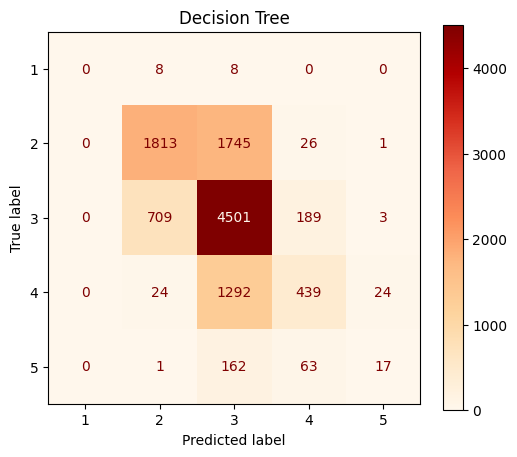

In [ ]:
#f1_weighted,weighted by class size,Skews toward the majority class.
f1_weighted_tree = f1_score(y_test, pred_tree, average='weighted')
print(f"F1_Score Weighted: {f1_weighted_tree:.3f}")

#f1_macro,every esi level counts equally
f1_macro_tree = f1_score(y_test, pred_tree, average='macro')
print(f"F1_Score Macro: {f1_macro_tree:.3f}")

#recall for esi1
recall_tree = recall_score(y_test, pred_tree, labels=[1], average=None, zero_division=0)[0]
print(f"Recall for ESI 1: {recall_tree:.3f}")

#classification report
print(f"\nClassification report:\n{classification_report(y_test, pred_tree, digits=3, zero_division=0)}")

#confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_tree,ax=ax, cmap="OrRd")
ax.set_title("Decision Tree")
fig.savefig("/content/drive/MyDrive/confusion_matrix_tree.png", dpi=150, bbox_inches="tight")
plt.show()

##Exploring Balanced Models ⚖🌳

In [ ]:
#a balanced decision tree to take account of the <1% esi 1
tree_bal = DecisionTreeClassifier(min_samples_leaf=20, class_weight="balanced", random_state=42)
tree_bal.fit(X_train, y_train)
pred_tree_bal = tree_bal.predict(X_test)

print(f"Train accuracy: {tree_bal.score(X_train, y_train):.3f}")
print(f"Test accuracy:  {tree_bal.score(X_test, y_test):.3f}")
print(f"\nF1 Weighted: {f1_score(y_test, pred_tree_bal, average='weighted'):.3f}")
print(f"F1 Macro: {f1_score(y_test, pred_tree_bal, average='macro'):.3f}")
print(f"Recall for ESI 1: {recall_score(y_test, pred_tree_bal, labels=[1], average=None, zero_division=0)[0]:.3f}")
print(f"\n{classification_report(y_test, pred_tree_bal, digits=3, zero_division=0)}")

Train accuracy: 0.590
Test accuracy:  0.516

F1 Weighted: 0.539
F1 Macro: 0.378
Recall for ESI 1: 0.500

              precision    recall  f1-score   support

           1      0.054     0.500     0.097        16
           2      0.617     0.604     0.610      3585
           3      0.699     0.433     0.535      5402
           4      0.380     0.582     0.460      1779
           5      0.110     0.588     0.186       243

    accuracy                          0.516     11025
   macro avg      0.372     0.541     0.378     11025
weighted avg      0.607     0.516     0.539     11025



In [ ]:
# balanced logistic regression
logreg_bal = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
logreg_bal.fit(X_train_scaled, y_train)
pred_logreg_bal = logreg_bal.predict(X_test_scaled)

print(f"Test accuracy: {logreg_bal.score(X_test_scaled, y_test):.3f}")
print(f"F1 Weighted: {f1_score(y_test, pred_logreg_bal, average='weighted'):.3f}")
print(f"F1 Macro: {f1_score(y_test, pred_logreg_bal, average='macro'):.3f}")
print(f"Recall for ESI 1: {recall_score(y_test, pred_logreg_bal, labels=[1], average=None)[0]:.3f}")
print(f"\nClassification report:\n{classification_report(y_test, pred_logreg_bal, digits=3, zero_division=0)}")

Test accuracy: 0.563
F1 Weighted: 0.596
F1 Macro: 0.411
Recall for ESI 1: 0.625

Classification report:
              precision    recall  f1-score   support

           1      0.017     0.625     0.032        16
           2      0.658     0.602     0.629      3585
           3      0.762     0.500     0.604      5402
           4      0.488     0.655     0.559      1779
           5      0.139     0.691     0.231       243

    accuracy                          0.563     11025
   macro avg      0.413     0.615     0.411     11025
weighted avg      0.669     0.563     0.596     11025



##Summary 📝

In [ ]:
#comparison of all models vs the dummy baseline
results = {}
for name, pred in [("Dummy", pred_dummy),
                   ("Logistic Regression", pred_logreg),
                   ("Decision Tree", pred_tree),
                   ("Logistic Regression (balanced)", pred_logreg_bal),
                   ("Decision Tree (balanced)", pred_tree_bal)]:
    r1, r2, r3, r4, r5 = recall_score(y_test, pred, labels=[1, 2, 3, 4, 5], average=None, zero_division=0)
    p1, p2, p3, p4, p5 = precision_score(y_test, pred, labels=[1, 2, 3, 4, 5], average=None, zero_division=0)
    results[name] = {
        "ESI1 Recall": r1, "ESI1 Precision": p1,
        "ESI2 Recall": r2, "ESI2 Precision": p2,
        "ESI3 Recall": r3, "ESI3 Precision": p3,
        "ESI4 Recall": r4, "ESI4 Precision": p4,
        "ESI5 Recall": r5, "ESI5 Precision": p5,
        "Accuracy": (pred == y_test).mean(),
        "F1 Weighted": f1_score(y_test, pred, average="weighted"),
        "F1 Macro": f1_score(y_test, pred, average="macro"),
    }

comparison = pd.DataFrame(results).T.round(3)
print(comparison)

                                ESI1 Recall  ESI1 Precision  ESI2 Recall  ESI2 Precision  ESI3 Recall  ESI3 Precision  \
Dummy                                 0.000           0.000        0.327           0.334        0.498           0.491   
Logistic Regression                   0.250           0.444        0.609           0.716        0.757           0.661   
Decision Tree                         0.000           0.000        0.506           0.710        0.833           0.584   
Logistic Regression (balanced)        0.625           0.017        0.602           0.658        0.500           0.762   
Decision Tree (balanced)              0.500           0.054        0.604           0.617        0.433           0.699   

                                ESI4 Recall  ESI4 Precision  ESI5 Recall  ESI5 Precision  Accuracy  F1 Weighted  \
Dummy                                 0.148           0.147        0.045           0.049     0.375        0.375   
Logistic Regression                   0.589

##Saving Trained Model 🤖

In [ ]:
save_model = Path("/content/drive/MyDrive/trained_models")
save_model.mkdir(exist_ok=True)

# scaler
joblib.dump(scaler, save_model / "scaler.joblib")

# unweighted models
joblib.dump(logreg, save_model / "model_logreg.joblib")
joblib.dump(tree,   save_model / "model_tree.joblib")

# class-weight balanced variants
joblib.dump(logreg_bal, save_model / "model_logreg_balanced.joblib")
joblib.dump(tree_bal,   save_model / "model_tree_balanced.joblib")

print("Saved to Drive!")

Saved to Drive!
